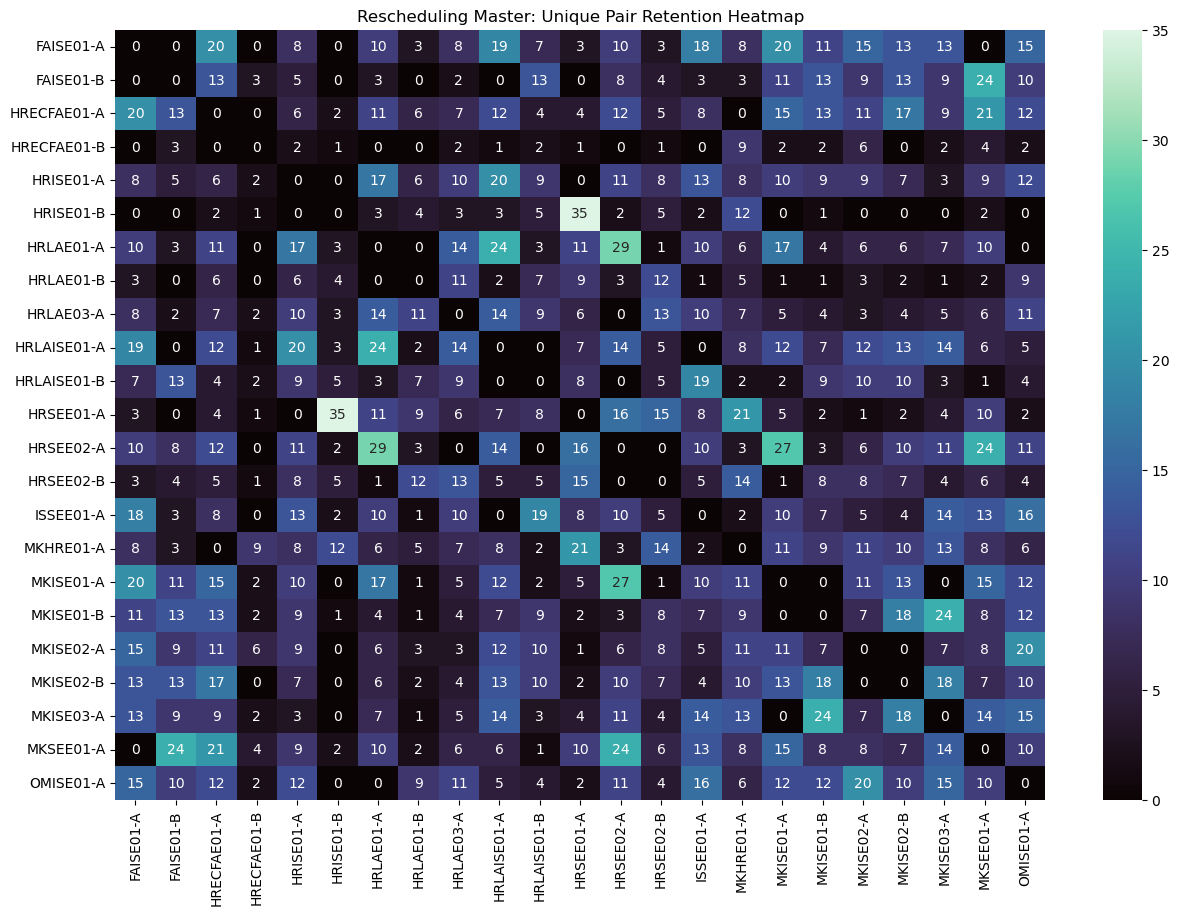

In [1]:
import pandas as pd
import numpy as np
import random
from collections import defaultdict
import math
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------ CONFIG ------------------
EXCEL_PATH = "Term 6 Consolidated.xlsx"
ID_COL = "Student Ids"
NAME_COL = "Student Names"
IGNORE_SHEETS = {"Sheet1"}

# PRIMARY CONSTRAINTS
MIN_STUDENTS = 40
MAX_STUDENTS = 80
COHORT_THRESHOLD = 3 
FROZEN_COURSES = ["MKSEE01", "MKHRE01", "HRSEE01", "OMISE01", "ISSEE01", "HRLAE03", "MKISE03"]

# ------------------ DATA LOADING ------------------
def load_data():
    xls = pd.ExcelFile(EXCEL_PATH)
    courses = [s for s in xls.sheet_names if s not in IGNORE_SHEETS]
    course_student_ids = {}
    course_raw_dfs = {}
    student_to_courses = defaultdict(set)
    
    for c in courses:
        df = pd.read_excel(xls, sheet_name=c).dropna(subset=[ID_COL])
        df[ID_COL] = df[ID_COL].astype(str).str.strip()
        ids = df[ID_COL].tolist()
        course_student_ids[c] = ids
        course_raw_dfs[c] = df
        for sid in ids:
            student_to_courses[sid].add(c)
            
    return course_student_ids, student_to_courses, course_raw_dfs

# ------------------ ANCHOR LOGIC (UNIQUE PAIRS) ------------------
def run_optimized_split(course_student_ids, course_raw_dfs, student_to_courses):
    course_names = list(course_student_ids.keys())
    non_frozen = [c for c in course_names if c not in FROZEN_COURSES]
    assignments = {c: {} for c in course_names}
    
    # 1. Handle Frozen Courses (Always Section A)
    for fc in FROZEN_COURSES:
        for sid in course_student_ids[fc]:
            assignments[fc][sid] = 0

    # 2. Create Unique Non-Overlapping Sections
    # We pair each Frozen Course with a Non-Frozen Course to create a 'Zero-Overlap' section
    used_non_frozen = set()
    for i, fc in enumerate(FROZEN_COURSES):
        if i < len(non_frozen):
            target_nf = non_frozen[i]
            used_non_frozen.add(target_nf)
            
            fc_students = set(course_student_ids[fc])
            nf_students = course_student_ids[target_nf]
            
            # To make Section A of the non-frozen course UNIQUE (non-overlapping with the frozen one):
            # We put all students who ARE in the frozen course into Section B of the non-frozen course.
            for sid in nf_students:
                if sid in fc_students:
                    assignments[target_nf][sid] = 1 # Force to B
                else:
                    assignments[target_nf][sid] = 0 # Put others in A

    # 3. Fill remaining Non-Frozen Courses & Re-balance
    for c in non_frozen:
        total_students = len(course_student_ids[c])
        ids = course_student_ids[c]
        
        # If not already partially assigned by the anchor logic
        if not assignments[c]:
            random.shuffle(ids)
            for j, sid in enumerate(ids):
                assignments[c][sid] = 0 if j < total_students // 2 else 1
        
        # Balance Check and Correction (Strict 40-80)
        curr_map = assignments[c]
        nA = sum(1 for v in curr_map.values() if v == 0)
        nB = len(curr_map) - nA
        
        # Shift students if balance is violated
        all_sids = list(curr_map.keys())
        while nA < MIN_STUDENTS or nA > MAX_STUDENTS:
            if nA < MIN_STUDENTS:
                # Move someone from B to A
                for s in all_sids:
                    if curr_map[s] == 1:
                        curr_map[s] = 0
                        nA += 1
                        break
            elif nA > MAX_STUDENTS:
                # Move someone from A to B
                for s in all_sids:
                    if curr_map[s] == 0:
                        curr_map[s] = 1
                        nA -= 1
                        break
    
    return assignments

# ------------------ EXPORT & MASTER MASTER ------------------
def export_with_rescheduling_master(assignments, course_raw_dfs):
    sections = []
    for c, amap in assignments.items():
        sections.append(f"{c}-A")
        if c not in FROZEN_COURSES: sections.append(f"{c}-B")
    
    # Calculate Overlap Matrix
    matrix = pd.DataFrame(0, index=sections, columns=sections)
    for i, s1 in enumerate(sections):
        c1, sec1_label = s1.rsplit('-', 1)
        sec1_val = 0 if sec1_label == 'A' else 1
        set1 = set(sid for sid, v in assignments[c1].items() if v == sec1_val)
        
        for j, s2 in enumerate(sections):
            if i >= j: continue
            c2, sec2_label = s2.rsplit('-', 1)
            sec2_val = 0 if sec2_label == 'A' else 1
            set2 = set(sid for sid, v in assignments[c2].items() if v == sec2_val)
            
            overlap = len(set1 & set2)
            matrix.loc[s1, s2] = overlap
            matrix.loc[s2, s1] = overlap

    output_fn = "IIM_Ranchi_Unique_Pair_Optimization.xlsx"
    with pd.ExcelWriter(output_fn) as writer:
        matrix.to_excel(writer, sheet_name="Rescheduling Master")
        for c, df in course_raw_dfs.items():
            amap = assignments[c]
            # Section A
            df_a = df[df[ID_COL].map(lambda x: amap.get(x)) == 0].copy()
            df_a.to_excel(writer, sheet_name=f"{c[:28]}-A", index=False)
            # Section B
            if c not in FROZEN_COURSES:
                df_b = df[df[ID_COL].map(lambda x: amap.get(x)) == 1].copy()
                if not df_b.empty:
                    df_b.to_excel(writer, sheet_name=f"{c[:28]}-B", index=False)

    # Plotting
    plt.figure(figsize=(15, 10))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="mako")
    plt.title("Rescheduling Master: Unique Pair Retention Heatmap")
    plt.show()

# Run script
c_student_ids, s_to_c, c_dfs = load_data()
final_assignments = run_optimized_split(c_student_ids, c_dfs, s_to_c)
export_with_rescheduling_master(final_assignments, c_dfs)

In [1]:
import pandas as pd
import numpy as np
import random
from collections import defaultdict

# ------------------ CONFIG ------------------
SLOTS_PER_DAY = 8
DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday","Sunday"]
LUNCH_SLOT = 4 
MAX_CLASSROOMS = 5 # Set this to the actual number of rooms available at Ranchi
OVERLAP_FILE = "IIM_Ranchi_Unique_Pair_Optimization.xlsx"

class IIMR_OptimizedScheduler:
    def __init__(self, overlap_path):
        # Load the Rescheduling Master data
        self.overlap_df = pd.read_excel(overlap_path, sheet_name="Rescheduling Master", index_col=0)
        self.sections = self.overlap_df.index.tolist()
        self.schedule = defaultdict(list) 
        self.section_sessions = defaultdict(int)
        
    def get_course_name(self, section_id):
        return section_id.rsplit('-', 1)[0]

    def is_slot_safe(self, section, day, slot):
        # 1. Classroom Capacity Check
        if len(self.schedule[(day, slot)]) >= MAX_CLASSROOMS:
            return False

        # 2. Daily Limit: One session per course per day
        # (Students shouldn't have the same subject twice in 24 hours)
        for s in self.schedule[(day, slot)]:
            if self.get_course_name(s) == self.get_course_name(section):
                return False
        
        # Check other slots in the SAME day for the same section
        for s_idx in range(1, SLOTS_PER_DAY + 1):
            for s in self.schedule[(day, s_idx)]:
                if s == section: return False

        # 3. Conflict Matrix: ZERO Overlap check
        # This uses the data we generated in the previous optimization step
        for other in self.schedule[(day, slot)]:
            if self.overlap_df.loc[section, other] > 0:
                return False

        return True

    def solve(self, section_list):
        """
        Backtracking solver to find a 100% valid schedule.
        """
        if not section_list:
            return True # All classes scheduled

        # Sort remaining sections by 'Difficulty' (those with most overlaps first)
        section = section_list[0]

        for day in DAYS:
            for slot in range(1, SLOTS_PER_DAY + 1):
                if slot == LUNCH_SLOT: continue
                
                if self.is_slot_safe(section, day, slot):
                    # Place class
                    self.schedule[(day, slot)].append(section)
                    
                    # Recurse
                    if self.solve(section_list[1:]):
                        return True
                    
                    # Backtrack (Undo)
                    self.schedule[(day, slot)].remove(section)

        return False

    def generate(self):
        # Every section needs 2 sessions per week
        full_queue = self.sections + self.sections
        # Priority: Schedule sections with the MOST total overlaps first 
        # (Constraintest-First Search)
        full_queue.sort(key=lambda x: self.overlap_df.loc[x].sum(), reverse=True)

        if self.solve(full_queue):
            print("Optimal schedule found!")
            return self.format_output()
        else:
            print("Could not find a valid schedule with current constraints.")
            return None

    def format_output(self):
        rows = []
        for day in DAYS:
            for slot in range(1, SLOTS_PER_DAY + 1):
                classes = self.schedule[(day, slot)]
                rows.append({
                    "Day": day,
                    "Slot": slot,
                    "Classes": ", ".join(classes),
                    "Room_Utilization": f"{len(classes)}/{MAX_CLASSROOMS}"
                })
        return pd.DataFrame(rows)

# ------------------ EXECUTION ------------------
scheduler = IIMR_OptimizedScheduler(OVERLAP_FILE)
timetable_df = scheduler.generate()

if timetable_df is not None:
    with pd.ExcelWriter("IIM_Ranchi_Most_Optimized_Timetable.xlsx") as writer:
        timetable_df.to_excel(writer, sheet_name="Full_List", index=False)
        
        # Create Visual Grid
        pivot = timetable_df.pivot(index='Slot', columns='Day', values='Classes').fillna("-")
        pivot = pivot.reindex(columns=DAYS)
        pivot.to_excel(writer, sheet_name="Visual_Grid")
        
    print(pivot)

Optimal schedule found!
Day                            Monday                          Tuesday  \
Slot                                                                     
1                HRSEE02-A, HRLAE03-A             HRSEE02-A, HRLAE03-A   
2              HRECFAE01-A, MKHRE01-A           HRECFAE01-A, MKHRE01-A   
3                MKSEE01-A, FAISE01-A             MKSEE01-A, FAISE01-A   
4                                                                        
5     MKISE01-A, MKISE03-A, HRISE01-B  MKISE01-A, MKISE03-A, HRISE01-B   
6              HRLAISE01-A, ISSEE01-A           HRLAISE01-A, ISSEE01-A   
7                OMISE01-A, HRLAE01-A             OMISE01-A, HRLAE01-A   
8              MKISE02-B, HRECFAE01-B           MKISE02-B, HRECFAE01-B   

Day              Wednesday              Thursday Friday Saturday Sunday  
Slot                                                                     
1     HRISE01-A, HRSEE01-A  HRISE01-A, HRSEE01-A                         
2            